In [1]:
print("Hello Krishna")

Hello Krishna


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


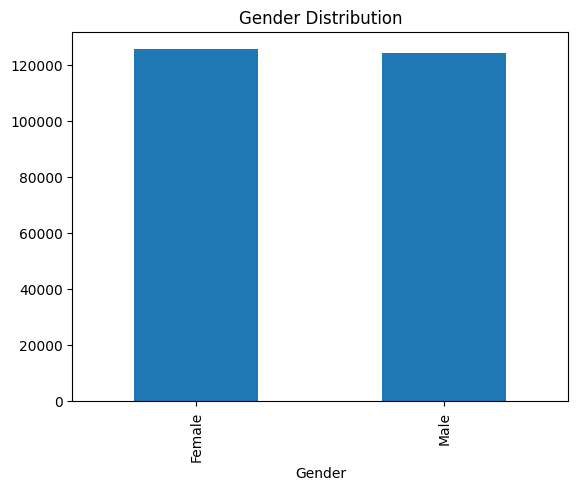

In [4]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

In [5]:
import pandas as pd

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [6]:
import datetime as dt

latest_date = df['Purchase Date'].max()
latest_date

Timestamp('2023-09-15 12:24:08')

In [7]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (latest_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [8]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [9]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
1,57,1,3491,5,1,1,511
2,298,3,7988,2,1,2,212
3,88,8,22587,4,5,5,455
4,126,4,8715,4,2,2,422
5,170,8,12524,3,5,3,353


In [10]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    elif row['R_score'] == 1:
        return 'Lost Customers'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Regular Customers    15301
At Risk              15186
Champions            10277
Loyal Customers       8909
Name: count, dtype: int64

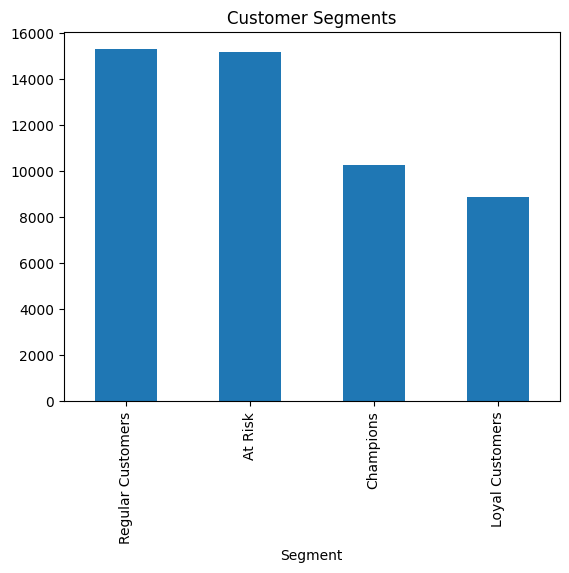

In [11]:
rfm['Segment'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Customer Segments")
plt.show()

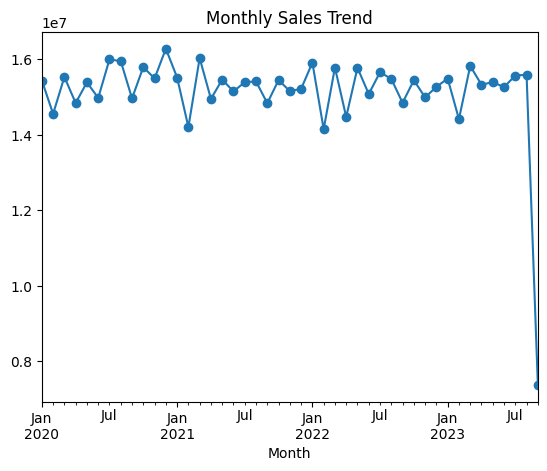

In [12]:
df['Month'] = df['Purchase Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

monthly_sales.plot(kind='line', marker='o')

import matplotlib.pyplot as plt
plt.title("Monthly Sales Trend")
plt.show()

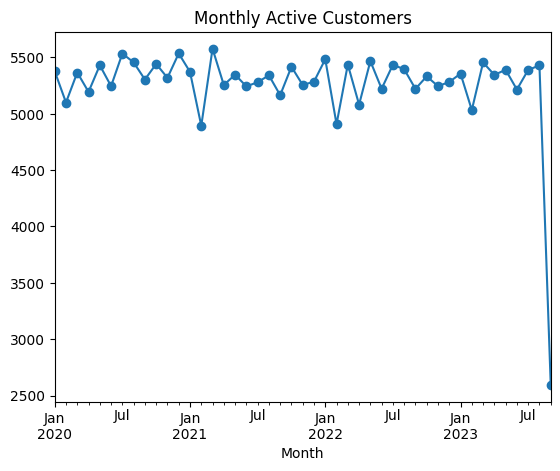

In [13]:
monthly_customers = df.groupby('Month')['Customer ID'].nunique()

monthly_customers.plot(kind='line', marker='o')

plt.title("Monthly Active Customers")
plt.show()

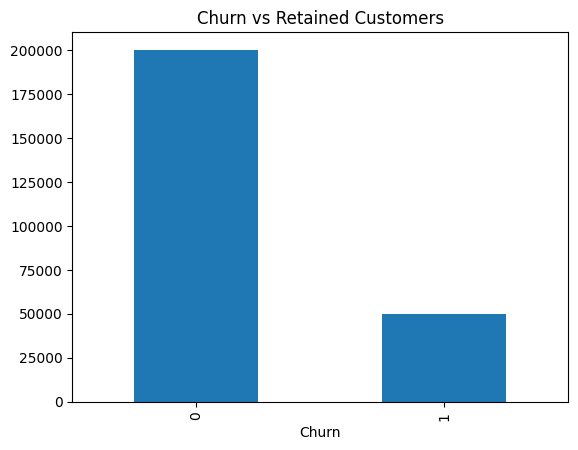

In [14]:
df.groupby('Churn')['Customer ID'].count().plot(kind='bar')

plt.title("Churn vs Retained Customers")
plt.show()